# 07 · Particiones espaciales y reserva

Fase E, pasos 27–28. Lee la ejecución D fijada en `config/evaluation.yaml`, verifica sus hashes y congela el protocolo. Consulte [LEEME_FASE_E.md](LEEME_FASE_E.md).

**El modo diagnóstico usa candidatos, no positivos confirmados.** Los bloques de 50 km y la separación de 5 km son hipótesis iniciales pendientes de revisión geológica.

In [2]:
from pathlib import Path
import sys
import importlib
import pandas as pd
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'src/geoau/evaluation.py').is_file())
if str(ROOT / 'src') not in sys.path: sys.path.insert(0, str(ROOT / 'src'))
from geoau import evaluation as ev
importlib.reload(ev)

RUN = ev.ensure_run(ROOT)
display(ev.read_json(RUN / "readiness.json"))

Fase E: C:\Users\Lenovo\Desktop\PROYECTO IA\GeoAI\GeoAI\reports\fase_e\20260924T160154_471445Z


{'ready_for_scientific_training': False,
 'reasons': ['No hay positivos revisados con soporte para este objetivo.',
  'Faltan deposit_id validados en los positivos.',
  'Faltan district_id validados en los positivos.',
  'D no contiene predictores aprobados para entrenamiento.',
  'Falta cartografía territorial de distritos: no basta con IDs en los indicios.',
  'Falta selección revisada de distritos para reserva final.',
  'Protocolo espacial pendiente de revisión.'],
 'reviewed_positive_cells': 0,
 'diagnostic_or_selected_positive_cells': 666,
 'selected_role': 'P_candidate_proxy'}

## Unidades completas y anidamiento
Los bloques conectados por un mismo depósito/distrito se unen transitivamente. En diagnóstico se añade el grupo de proximidad de 500 m, sin equipararlo a un depósito. La reserva geográfica se elige por semilla antes del ajuste. Las particiones internas solo acceden al entrenamiento externo.

In [3]:
summary = ev.build_splits(ROOT, RUN)
display(summary)
display(pd.read_csv(RUN / "block_sensitivity.csv"))
display(ev.read_json(RUN / "split_plan.json"))

Particiones externo/internas: 0
Particiones externo/internas: 1
Particiones externo/internas: 2
Particiones externo/internas: 3
Particiones externo/internas: 4


,split_id,train_cells,test_cells,train_p_cells,test_p_cells,train_p_units,test_p_units,minimum_train_test_holdout_gap_lower_bound_m,unit_overlap
0,outer_00,286889,67947,378,189,37,10,5293.99037,0
1,outer_00_inner_00,165916,97931,277,88,25,11,5293.99037,0
2,outer_00_inner_01,175415,91214,178,163,22,15,5293.99037,0
3,outer_00_inner_02,164232,97744,219,127,26,11,5293.99037,0
4,outer_01,265282,85001,498,108,42,8,5293.99037,0
5,outer_01_inner_00,153823,91071,362,103,27,12,5293.99037,0
6,outer_01_inner_01,157315,89523,234,219,28,13,5293.99037,0
7,outer_01_inner_02,163523,84688,290,176,23,17,5293.99037,0
8,outer_02,256071,93064,468,123,36,10,5293.99037,0
9,outer_02_inner_00,148899,89162,287,145,24,11,5293.99037,0


,block_size_m,blocks,units,units_with_selected_P,scope
0,25000,888,888,109,diagnostico de agrupación; no estima autocorre...
1,50000,246,246,61,diagnostico de agrupación; no estima autocorre...
2,100000,72,72,30,diagnostico de agrupación; no estima autocorre...


{'mode': 'diagnostic',
 'outer_folds': 5,
 'attempts': [{'outer_folds': 5, 'feasible': True}],
 'splits': [{'split_id': 'outer_00',
   'level': 'outer',
   'outer_fold': 0,
   'inner_fold': None,
   'evaluation_role': 'test'},
  {'split_id': 'outer_00_inner_00',
   'level': 'inner',
   'outer_fold': 0,
   'inner_fold': 0,
   'evaluation_role': 'validation'},
  {'split_id': 'outer_00_inner_01',
   'level': 'inner',
   'outer_fold': 0,
   'inner_fold': 1,
   'evaluation_role': 'validation'},
  {'split_id': 'outer_00_inner_02',
   'level': 'inner',
   'outer_fold': 0,
   'inner_fold': 2,
   'evaluation_role': 'validation'},
  {'split_id': 'outer_01',
   'level': 'outer',
   'outer_fold': 1,
   'inner_fold': None,
   'evaluation_role': 'test'},
  {'split_id': 'outer_01_inner_00',
   'level': 'inner',
   'outer_fold': 1,
   'inner_fold': 0,
   'evaluation_role': 'validation'},
  {'split_id': 'outer_01_inner_01',
   'level': 'inner',
   'outer_fold': 1,
   'inner_fold': 1,
   'evaluation_rol

La tabla 25/50/100 km describe agrupación y disponibilidad de unidades. **No mide autocorrelación ni demuestra que 50 km sea óptimo.** La reducción de folds comprueba factibilidad; no maximiza una métrica de rendimiento.

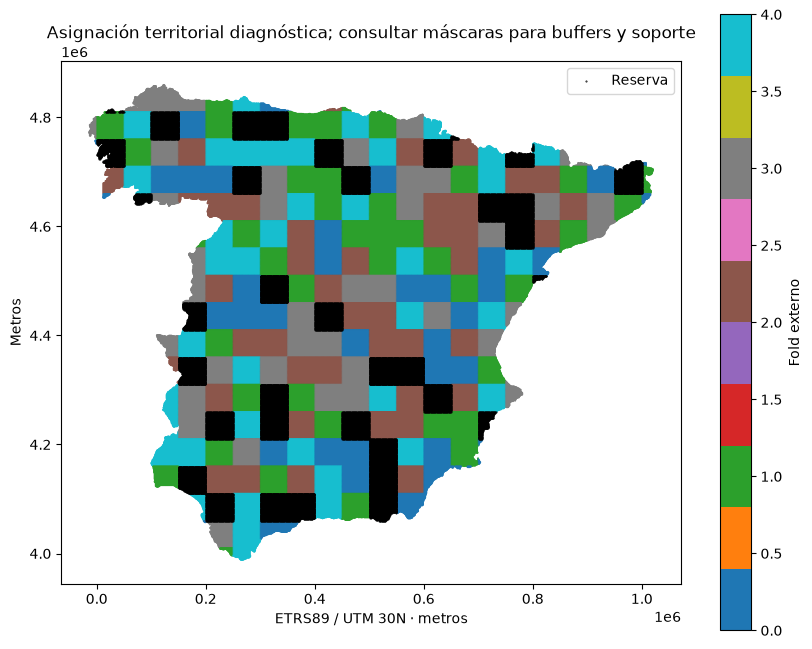

In [4]:
import matplotlib.pyplot as plt
territory = pd.read_parquet(RUN / 'territory.parquet')
units = pd.read_parquet(RUN / 'design/spatial_units.parquet')
view = territory.merge(units, on='cell_id', validate='one_to_one')
fig, ax = plt.subplots(figsize=(10, 8))
development = view[~view.holdout]
plot = ax.scatter(development.x_center, development.y_center,
                  c=development.outer_fold, cmap='tab10', s=.2, rasterized=True)
reserve = view[view.holdout]
ax.scatter(reserve.x_center, reserve.y_center, color='black', s=.2, label='Reserva')
ax.set(aspect='equal', xlabel='ETRS89 / UTM 30N · metros', ylabel='Metros',
       title='Asignación territorial diagnóstica; consultar máscaras para buffers y soporte')
ax.legend(); fig.colorbar(plot, ax=ax, label='Fold externo'); plt.show()